# 384-Well Plate: Exploratory Data Analysis

This notebook looks at the tidy 384-well dataset visually and descriptively, before any modelling.

An initial pass at identifying which sensors discriminate wines used a single fixed wavelength band (550-650nm). That fixed-band framing turned out to be limiting, and motivated a systematic per-wavelength F-statistic scan later in this notebook. The numbers computed in this notebook are exploratory and recomputed in 03_384well_Analysis.ipynb.

## Imports and data load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import string
import matplotlib.patches as mpatches

In [3]:
master_df_384 = pd.read_csv("../../data/processed/master_df_384.csv")

## Initial inspection

In [4]:
master_df_384.head()

,Wavelength,Well,Absorbance,Plate,Peptide,Sensor,Wine,Replicate
0,350,A1,0.1146,W1_4_384,NaN,Wine control,W1,1
1,352,A1,0.1115,W1_4_384,NaN,Wine control,W1,1
2,354,A1,0.1087,W1_4_384,NaN,Wine control,W1,1
3,356,A1,0.1054,W1_4_384,NaN,Wine control,W1,1
4,358,A1,0.1028,W1_4_384,NaN,Wine control,W1,1


In [5]:
master_df_384.tail()

,Wavelength,Well,Absorbance,Plate,Peptide,Sensor,Wine,Replicate
260347,792,P24,0.0443,W9_12_384,NaN,Wine control,W12,6
260348,794,P24,0.0441,W9_12_384,NaN,Wine control,W12,6
260349,796,P24,0.0441,W9_12_384,NaN,Wine control,W12,6
260350,798,P24,0.0441,W9_12_384,NaN,Wine control,W12,6
260351,800,P24,0.0439,W9_12_384,NaN,Wine control,W12,6


In [6]:
master_df_384.shape

(260352, 8)

In [7]:
master_df_384.columns

Index(['Wavelength', 'Well', 'Absorbance', 'Plate', 'Peptide', 'Sensor',
       'Wine', 'Replicate'],
      dtype='object')

In [8]:
master_df_384.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260352 entries, 0 to 260351
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Wavelength  260352 non-null  int64  
 1   Well        260352 non-null  object 
 2   Absorbance  260352 non-null  float64
 3   Plate       260352 non-null  object 
 4   Peptide     227808 non-null  float64
 5   Sensor      260352 non-null  object 
 6   Wine        260352 non-null  object 
 7   Replicate   260352 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 15.9+ MB


## Data quality checks

In [9]:
master_df_384.isnull().sum().sort_values(ascending = False)

Peptide       32544
Wavelength        0
Well              0
Absorbance        0
Plate             0
Sensor            0
Wine              0
Replicate         0
dtype: int64

Peptide is null exactly where Sensor is "Wine control" (rows A and P — wine present, no sensor chemistry), which is expected, not missing data to be concerned about.

In [10]:
master_df_384.duplicated().sum()

np.int64(0)

In [11]:
master_df_384.describe()

,Wavelength,Absorbance,Peptide,Replicate
count,260352.000000,260352.000000,227808.000000,260352.000000
mean,575.000000,0.100116,7.500000,3.500000
std,130.480134,0.073040,4.031138,1.707828
min,350.000000,0.038600,1.000000,1.000000
25%,462.000000,0.049600,4.000000,2.000000
50%,575.000000,0.065500,7.500000,3.500000
75%,688.000000,0.111500,11.000000,5.000000
max,800.000000,0.313800,14.000000,6.000000


## Preliminary discrimination check (exploratory — fixed 550-650nm band)

A single fixed wavelength band, chosen by eye rather than systematically, is used here to get a first sense of which sensors discriminate wines. The systematic version — scanning every wavelength for every sensor, with no assumed band — appears later in this notebook and is the version actually carried forward into 03_384well_Analysis.ipynb.

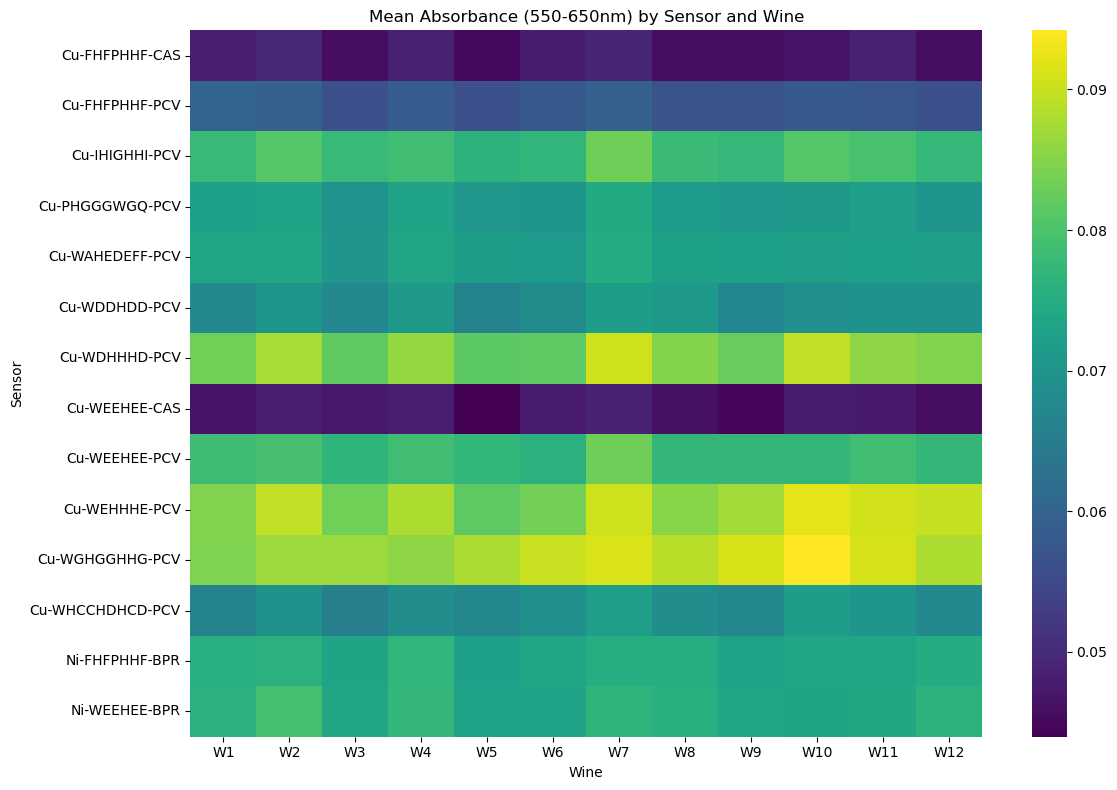

In [12]:
#Peptide x wine discrimination heatmap - using 550-650 nm peak

def wine_key(w):
    return int(w[1:])

wine_order = sorted(master_df_384["Wine"].unique(), key = wine_key)

peak_band = master_df_384[
    (master_df_384["Wavelength"] >= 550) &
    (master_df_384["Wavelength"] <= 650) &
    (master_df_384["Sensor"] != "Wine control")
]

discrimination = peak_band.pivot_table(
    values = "Absorbance",
    index = "Sensor",
    columns = "Wine",
    aggfunc = "mean"
)

discrimination = discrimination[wine_order]

plt.figure(figsize = (12, 8))
sns.heatmap(discrimination, cmap = "viridis", annot = False)
plt.title("Mean Absorbance (550-650nm) by Sensor and Wine")
plt.tight_layout()
plt.show()

All six wines follow the same overall shape (rise to a peak around 440-460nm, decay to a near-flat baseline by 500-800nm), but W5 and W6 sit visibly higher than W1-W4 in the 300-400nm shoulder region.

This plot pools every peptide together, so the separation visible here is dominated by whichever peptides respond most strongly. However, wine itself has intrinsic color and UV absorbance (tannins) independent of any sensor chemistry. W5/W6 standing apart here may simply reflect those two wines being darker or more tannic, rather than the sensing array discriminating them well. This confound is why the baseline correction against the wine-only control wells in 03_384well_Analysis.ipynb is a necessary step before any discrimination claim.

              Sensor  F_statistic        p_value
10     Cu-WEHHHE-PCV    89.778765  1.229240e-180
7     Cu-FHFPHHF-CAS    86.488930  1.756705e-174
9      Cu-WEEHEE-CAS    68.907961  8.606316e-141
8      Cu-WDHHHD-PCV    60.309242  8.267276e-124
6    Cu-WGHGGHHG-PCV    59.920272  4.938736e-123
0     Cu-IHIGHHI-PCV    31.824329   4.107998e-65
5   Cu-WHCCHDHCD-PCV    26.497619   9.663298e-54
4     Cu-FHFPHHF-PCV    23.996229   2.290434e-48
12     Cu-WDDHDD-PCV    20.702717   2.909112e-41
1      Cu-WEEHEE-PCV    17.518810   2.240728e-34
3    Cu-PHGGGWGQ-PCV    11.617302   1.249999e-21
2    Cu-WAHEDEFF-PCV     8.715864   1.938624e-15
13     Ni-WEEHEE-BPR     2.043738   2.117845e-02
11    Ni-FHFPHHF-BPR     1.020146   4.251681e-01


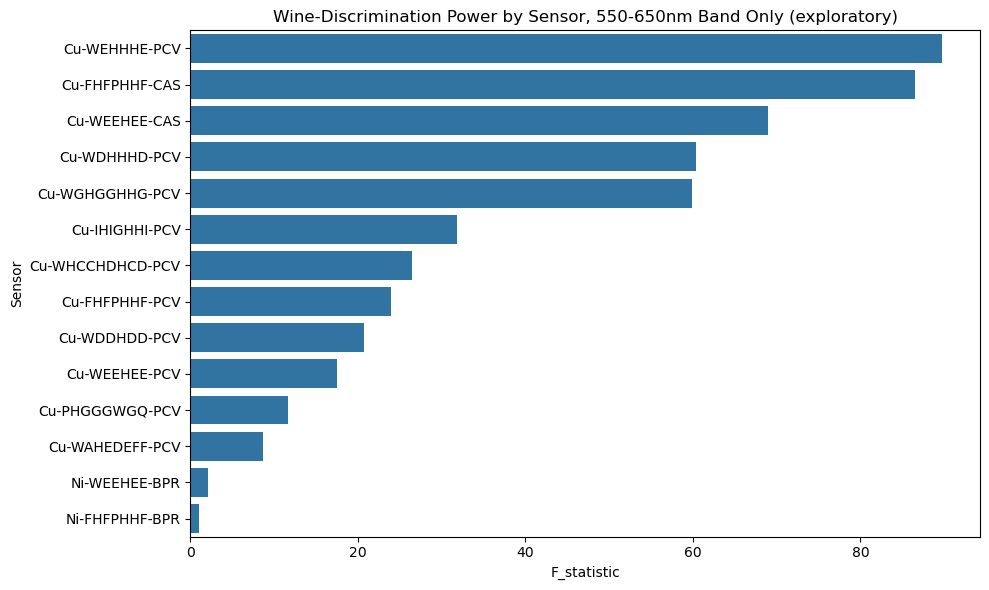

In [13]:
#Separation score per sensor (exploratory, fixed-band)

scores = []
for sensor in peak_band["Sensor"].unique():
    sensor_data = peak_band[peak_band["Sensor"] == sensor]
    groups = [g["Absorbance"].values for _, g in sensor_data.groupby("Wine")]
    f_stat, p_val = stats.f_oneway(*groups)
    scores.append({"Sensor": sensor, "F_statistic": f_stat, "p_value": p_val})

separation_scores = pd.DataFrame(scores).sort_values("F_statistic", ascending = False)
print(separation_scores)

plt.figure(figsize = (10, 6))
sns.barplot(data = separation_scores, y = "Sensor", x = "F_statistic")
plt.title("Wine-Discrimination Power by Sensor, 550-650nm Band Only (exploratory)")
plt.tight_layout()
plt.show()

Pooling absorbance across a fixed 100nm band only picks up the biggest color differences (W5/W6 vs. the rest) and washes out any subtler wine-to-wine separation that individual sensors, at their own specific wavelengths, might be capturing. This is why looking at every wavelength individually and by sensor is important.

In [ ]:
separation_scores.to_csv("../../data/processed/separation_scores.csv", index = False)

### Wine control corrected spectrum, top sensor by the exploratory ranking above

A first look at what the wine-control baseline correction does to the spectrum of the sensor that scored highest in the fixed-band pass above.

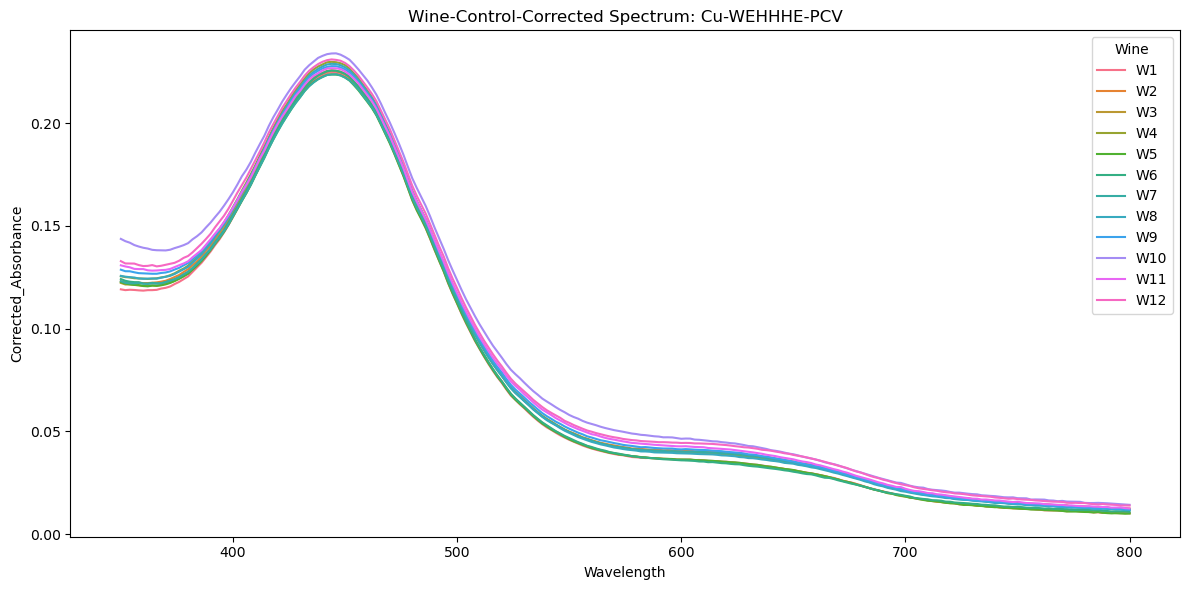

In [15]:
#Wine control corrected spectra for top 2-3 sensors

control = master_df_384[master_df_384["Sensor"] == "Wine control"]
control_baseline = control.groupby(["Wine", "Wavelength"])["Absorbance"].mean().reset_index()
control_baseline = control_baseline.rename(columns = {"Absorbance": "Control_Absorbance"})

top_sensor = separation_scores.iloc[0]["Sensor"]
sensor_data = master_df_384[master_df_384["Sensor"] == top_sensor]

corrected = sensor_data.merge(control_baseline, on = ["Wine", "Wavelength"], how = "left")
corrected["Corrected_Absorbance"] = corrected["Absorbance"] - corrected["Control_Absorbance"]

plt.figure(figsize = (12, 6))
sns.lineplot(data = corrected, x = "Wavelength", y = "Corrected_Absorbance", hue = "Wine", estimator = "mean", errorbar = None)
plt.title(f"Wine-Control-Corrected Spectrum: {top_sensor}")
plt.tight_layout()
plt.show()

## Systematic wavelength scan (no assumed band)

Instead of assuming a band, the F-statistic is computed at every individual wavelength, for every sensor, with no prior assumption about where the discriminating signal sits. This is the version that informs 03_384well_Analysis.ipynb's compact feature vector.

In [ ]:
#F-statistic at every wavelength, for every sensor

wavelength_scores = []

for sensor in master_df_384[master_df_384["Sensor"] != "Wine control"]["Sensor"].unique():
    sensor_data = master_df_384[master_df_384["Sensor"] == sensor]

    for wavelength in sensor_data["Wavelength"].unique():
        wl_data = sensor_data[sensor_data["Wavelength"] == wavelength]
        groups = [g["Absorbance"].values for _, g in wl_data.groupby("Wine")]
        f_stat, p_val = stats.f_oneway(*groups)
        wavelength_scores.append({
            "Sensor": sensor,
            "Wavelength": wavelength,
            "F_statistic": f_stat,
            "p_value": p_val
        })

wavelength_scores = pd.DataFrame(wavelength_scores)

In [ ]:
#Kept for reference
wavelength_scores.to_csv("../../data/processed/wavelength_scores.csv", index = False)

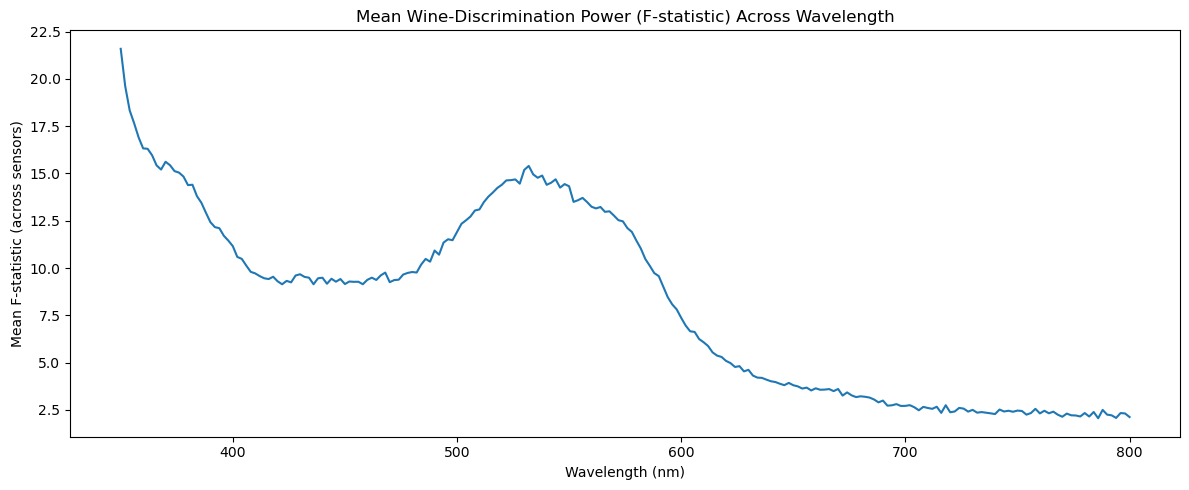

In [18]:
mean_by_wavelength = wavelength_scores.groupby("Wavelength")["F_statistic"].mean()

plt.figure(figsize = (12, 5))
plt.plot(mean_by_wavelength.index, mean_by_wavelength.values)
plt.title("Mean Wine-Discrimination Power (F-statistic) Across Wavelength")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean F-statistic (across sensors)")
plt.tight_layout()
plt.show()

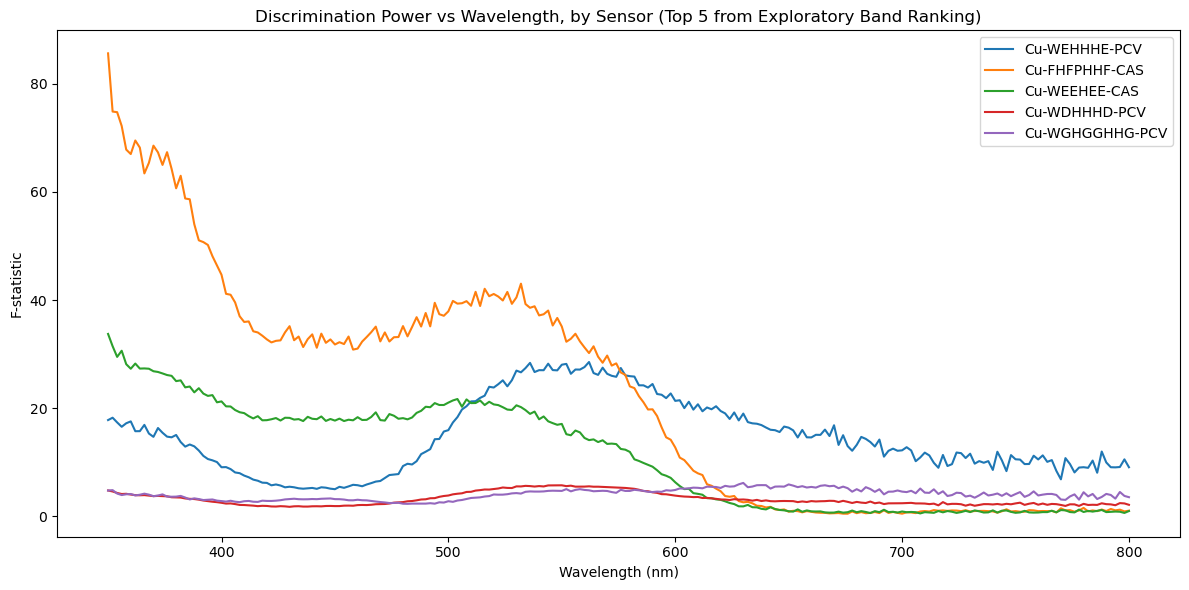

In [19]:
top_sensors = separation_scores.head(5)["Sensor"]

plt.figure(figsize = (12, 6))
for sensor in top_sensors:
    subset = wavelength_scores[wavelength_scores["Sensor"] == sensor]
    plt.plot(subset["Wavelength"], subset["F_statistic"], label = sensor)

plt.legend()
plt.title("Discrimination Power vs Wavelength, by Sensor (Top 5 from Exploratory Band Ranking)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("F-statistic")
plt.tight_layout()
plt.show()

Sensors 1-7 show a single clean peak around 440-460nm, with wine-to-wine spread that's small except right at the edges. Sensors 8-14 show a second feature,
a rising shoulder at the low-wavelength end (around 300nm) that decays before the main peak, and this is where the wine lines actually fan out, especially W5/W6 pulling away from W1-W4. Above ~500nm, every sensor panel goes flat. No wine separates from any other wine, regardless of sensor. The real discriminating signal sits closer to 300-460nm, not 550-650nm, and it is sensor-dependent rather than uniform across the array.

Plate layout figure to put in the methods section.

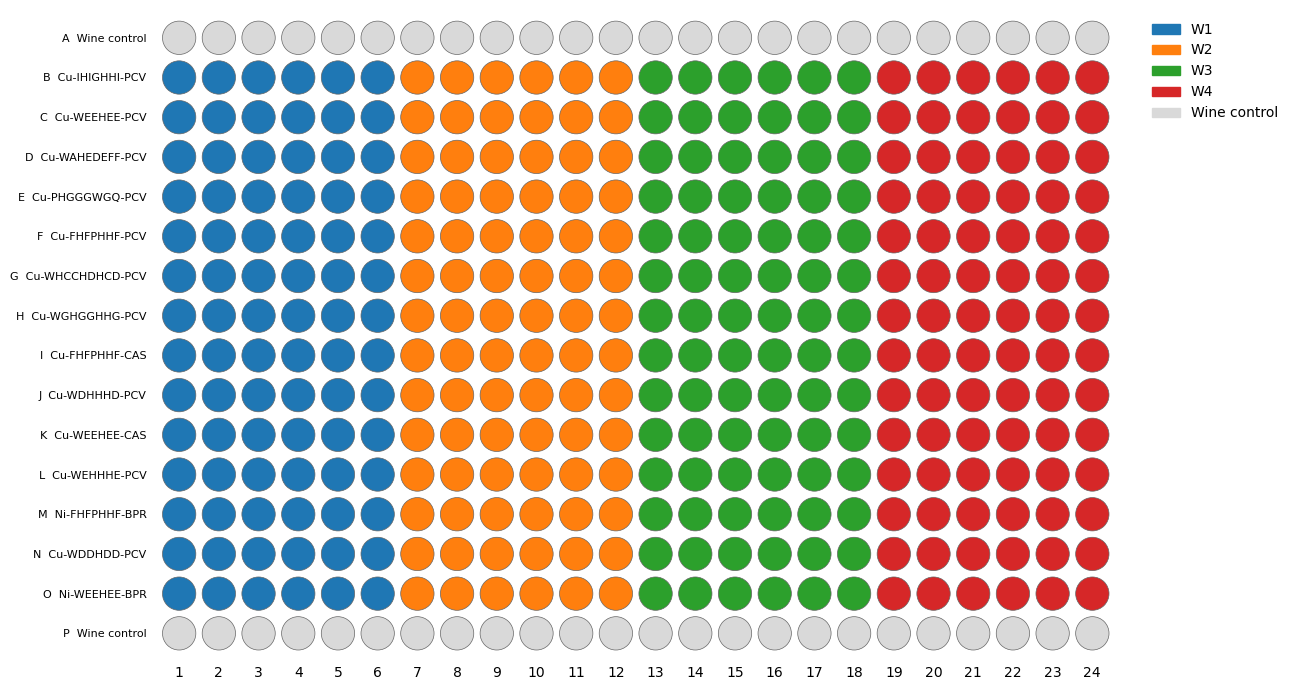

In [20]:
plate = "W1_4_384"         
df = master_df_384[master_df_384["Plate"] == plate]

rows = list(string.ascii_uppercase[:16])   # A–P
cols = range(1, 25)

wines = sorted(df.loc[df["Sensor"] != "Wine control", "Wine"].unique())
palette = dict(zip(wines, plt.cm.tab10.colors))

fig, ax = plt.subplots(figsize=(12, 7))

# one label per row, taken from the data
row_labels = []
for i, r in enumerate(rows):
    row_wells = df[df["Well"].str.match(rf"^{r}\d+$")]
    if row_wells.empty:
        row_labels.append("")
        continue
    sensors = row_wells["Sensor"].unique()
    row_labels.append(sensors[0] if len(sensors) == 1 else "mixed")

    for c in cols:
        well = row_wells[row_wells["Well"] == f"{r}{c}"]
        if well.empty:
            continue
        sensor = well["Sensor"].iloc[0]
        wine = well["Wine"].iloc[0]
        colour = "0.85" if sensor == "Wine control" else palette[wine]
        ax.add_patch(plt.Circle((c, -i), 0.42, facecolor=colour,
                                edgecolor="0.4", linewidth=0.5))

ax.set_xlim(0.3, 24.7)
ax.set_ylim(-15.7, 0.7)
ax.set_xticks(list(cols))
ax.set_yticks([-i for i in range(16)])
ax.set_yticklabels([f"{r}  {lab}" for r, lab in zip(rows, row_labels)], fontsize=8)
ax.set_aspect("equal")
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)

ax.legend(handles=[mpatches.Patch(color=palette[w], label=w) for w in wines]
                  + [mpatches.Patch(color="0.85", label="Wine control")],
          bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.show()